In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# load_boston has been removed, so we will get the data from the original source
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the Boston Housing dataset from the original source
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Define feature names based on common usage of the Boston Housing dataset
feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

# Create a DataFrame for better viewing
df = pd.DataFrame(data, columns=feature_names)
df['PRICE'] = target

X = data
y = target

print("Dataset loaded successfully. First 5 rows:")
display(df.head())

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_17935/1635227485.py:3: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Dataset loaded successfully. First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Training features shape: (404, 13)
Testing features shape: (102, 13)


In [8]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


history = model.fit(
    X_train_scaled, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("Model training complete.")

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 574.7817 - mae: 21.9738 - val_loss: 474.4101 - val_mae: 20.1337
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 473.8708 - mae: 19.6076 - val_loss: 350.9880 - val_mae: 16.8592
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 315.7330 - mae: 15.3169 - val_loss: 179.1098 - val_mae: 11.4480
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 143.2009 - mae: 9.8058 - val_loss: 55.7993 - val_mae: 5.4118
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 67.8607 - mae: 6.4387 - val_loss: 35.7282 - val_mae: 4.1424
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 45.0088 - mae: 5.1763 - val_loss: 29.5590 - val_mae: 3.6873
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 30.2578 - mae: 4.0973 - val_loss: 28.4902 - val_mae: 3.7171
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 23.9001 - mae: 3.5917 - val_loss: 26.8684 - val_mae: 3.6318
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━

Test Loss (MSE): 22.17
Test MAE: 3.25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


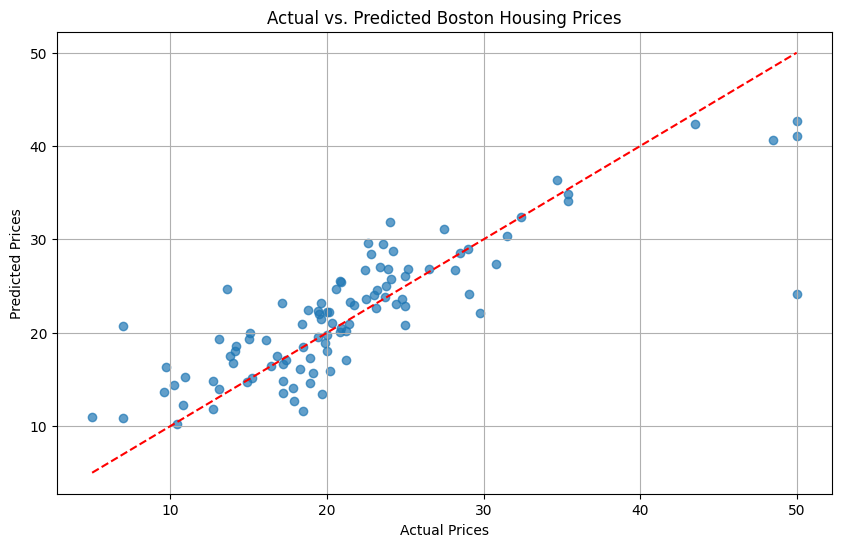

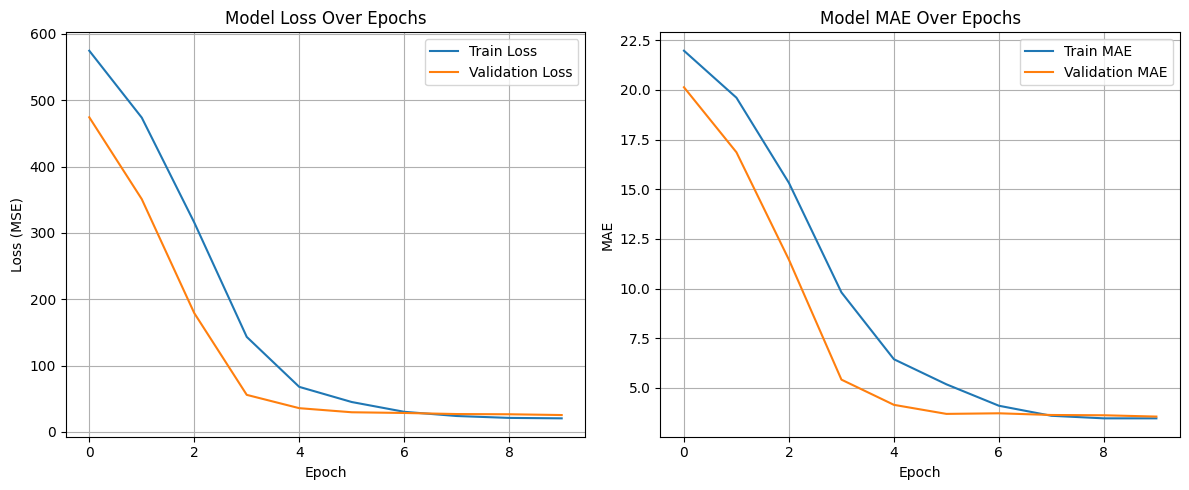

In [10]:
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.2f}")
print(f"Test MAE: {mae:.2f}")

y_pred = model.predict(X_test_scaled).flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Boston Housing Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()